# Apple Dataset

**Features**:
1. A_id
2. Size
3. Weight
4. Sweetness
5. Crunchiness
6. Juiciness
7. Ripeness
8. Acidity
9. Quality 

![imagen](https://storage.googleapis.com/kaggle-datasets-images/4291772/7384155/168acfd1f6ff796e7d9cd23602494f15/dataset-cover.jpeg?t=2024-01-11-14-32-08)


In [41]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

In [27]:
np.set_printoptions(suppress=True, precision=2)
data = np.genfromtxt("../apple_quality.csv", delimiter=",",skip_header=1,skip_footer=1)
print(data)
#Cambiar los str en numbers

print("----------------------------------------------")

data_str = np.genfromtxt("../apple_quality.csv", delimiter=",", dtype="str",skip_header=1,skip_footer=1)

[[   0.     -3.97   -2.51 ...    0.33   -0.49     nan]
 [   1.     -1.2    -2.84 ...    0.87   -0.72     nan]
 [   2.     -0.29   -1.35 ...   -0.04    2.62     nan]
 ...
 [3997.     -2.63   -2.14 ...    4.76   -1.33     nan]
 [3998.     -4.01   -1.78 ...    0.21   -2.23     nan]
 [3999.      0.28   -1.72 ...   -0.78    1.6      nan]]
----------------------------------------------


Seleccionamos las variables(x) y las etiquetas (y):
- x tiene las caracteristicas numericas de cada manzana
- y contiene la calidad, lo que esperamos predecir si es good or bad

In [28]:
x = data[:,:-1] # 
y = data_str[:,-1] # etiquetas 
print(y)

['good' 'good' 'bad' ... 'bad' 'good' 'good']


Funciones para mezclar el dataset y para dividir los datos de entreno y los datos de test

In [29]:
def mezclar(x,y):
    y_num = np.array([1 if val == 'good' else 0 for val in y]) # para que la y no sea un string 1 para good y 0 para bad
    data = np.column_stack((x, y_num))  # lo usamos para crear un unico array 
    np.random.shuffle(data) # mezclamos 
    return data[:, :-1], data[:, -1] # volvemos a separar


def data_splitter(x, y, porcentaje):
    corte = int(len(x) * porcentaje)
    return x[:corte], y[:corte], x[corte:], y[corte:]

En este caso usaremos el 70% de datos para el entreno y un 30% para el test

In [30]:
x, y = mezclar(x,y)
print(x)
X_train, y_train, X_test, y_test = data_splitter(x, y, 0.7)

[[1192.      1.99   -1.21 ...   -0.13    0.8    -1.07]
 [2419.     -5.07    1.51 ...   -0.81   -0.87   -2.65]
 [1775.     -2.75    1.19 ...   -0.      0.96   -0.03]
 ...
 [3875.     -0.83   -2.07 ...   -0.44    5.     -2.56]
 [1586.      2.12   -1.23 ...    1.95   -0.27   -0.95]
 [3589.     -0.21    1.15 ...    0.13   -2.31    2.59]]


#### Arbol de decision

0.7216666666666667


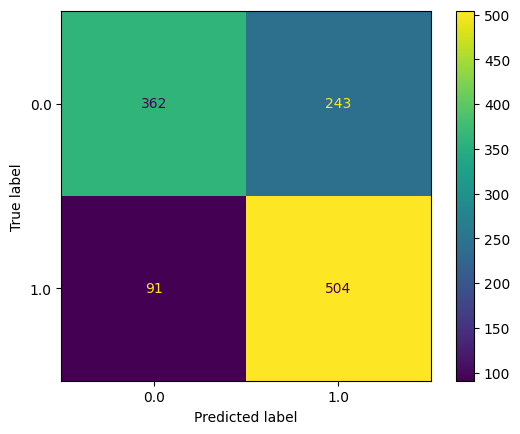

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
arbol = DecisionTreeClassifier(max_depth=3) # para no poner tantas decisiones
arbol.fit(X_train,y_train)
prediccion = arbol.predict(X_test)
accuracy = accuracy_score(y_test,prediccion)
print(accuracy)
ConfusionMatrixDisplay.from_predictions(y_test,prediccion)


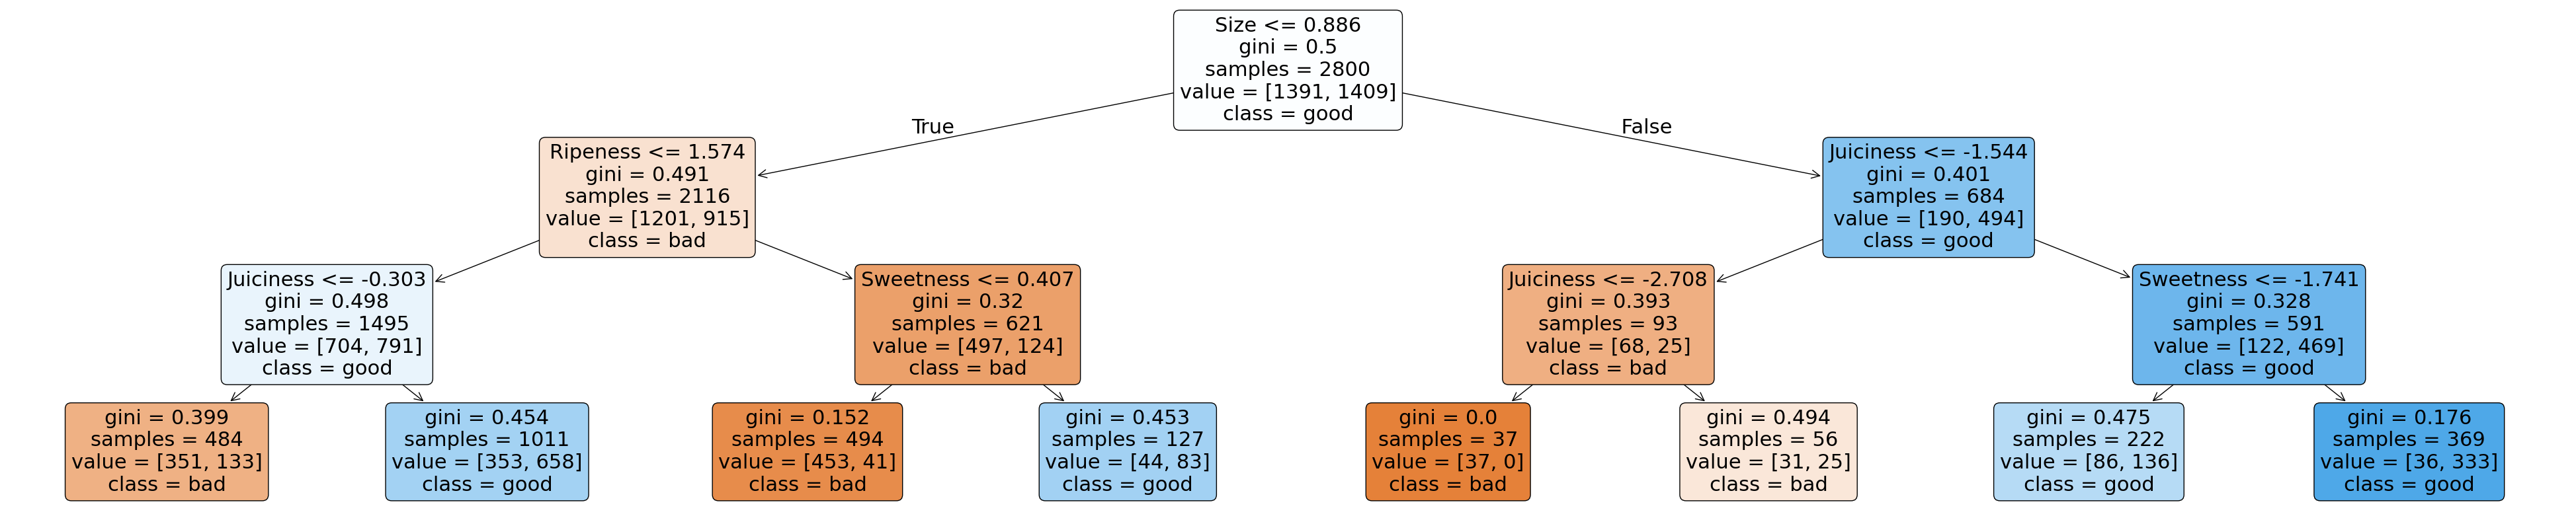

In [40]:
from sklearn import tree
import matplotlib.pyplot as plt

feature_names = ["A_id", "Size","Weight","Sweetness","Crunchiness","Juiciness","Ripeness","Acidity"]

plt.figure(figsize=(50,10))
tree.plot_tree(arbol,
               feature_names=feature_names,
               class_names=["bad","good"], # 0 es bad y 1 es good
               filled=True,
               rounded=True)
plt.show()

